# Hospital Readmission Predictions

### Exploratory Data Analysis 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import(
OneHotEncoder,StandardScaler
)
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("../data/raw/diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
df.shape

(101766, 50)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [7]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [8]:
df = df.replace("?",np.nan)

In [9]:
df.isnull().sum().sort_values(ascending=False)

weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
encounter_id                    0
troglitazone                    0
tolbutamide                     0
pioglitazone                    0
rosiglitazone                   0
acarbose                        0
miglitol                        0
citoglipton                     0
tolazamide                      0
examide                         0
glipizide                       0
insulin                         0
glyburide-metformin             0
glipizide-metformin             0
glimepiride-pioglitazone        0
metformin-rosiglitazone         0
metformin-pioglitazone          0
change                          0
diabetesMed                     0
glyburide                       0
repaglinide   

In [10]:
df["target"] = df["readmitted"].apply(
    lambda x: 1 if x == "<30" else 0
)
df["target"].value_counts()

target
0    90409
1    11357
Name: count, dtype: int64

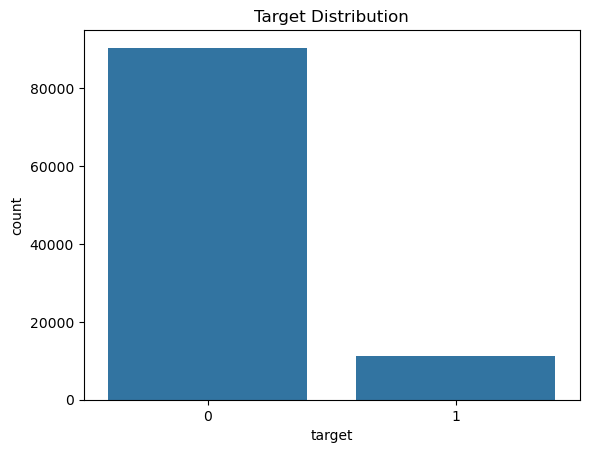

In [11]:
sns.countplot(x=df["target"])
plt.title("Target Distribution")
plt.show()

In [12]:
drop_cols = [
    "encounter_id",
    "patient_nbr",
    "readmitted"
]

df = df.drop(columns=drop_cols)

In [13]:
df.shape

(101766, 48)

In [14]:
# **Handling Leakage
df = df.drop(columns=["discharge_disposition_id"])

In [15]:
# Handling missing values
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

numeric_cols = df.select_dtypes(exclude="object").columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [16]:
# Handling Age
def convert_age(age):
    age = age.strip("[)")
    start, end = age.split("-")
    return (int(start) + int(end)) / 2

df["age"] = df["age"].apply(convert_age)

In [17]:
# Creating ICD Groupe
def categorize_diagnosis(diag):

    try:
        diag = float(diag)

        if 390 <= diag <= 459:
            return "Circulatory"

        elif 460 <= diag <= 519:
            return "Respiratory"

        elif 520 <= diag <= 579:
            return "Digestive"

        elif 250 <= diag < 251:
            return "Diabetes"

        else:
            return "Other"

    except:
        return "Unknown"

diag_cols = ["diag_1", "diag_2", "diag_3"]

for col in diag_cols:
    df[col] = df[col].apply(categorize_diagnosis)

In [18]:
X = df.drop(columns=["target"])
y = df["target"]

In [19]:
categorical_features = X.select_dtypes(include="object").columns

numeric_features = X.select_dtypes(exclude="object").columns

In [20]:
# Numerical Pipeline
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [21]:
# Categorical Pipeline
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [22]:
# Combine Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [23]:
X_processed = preprocessor.fit_transform(X)

print(X_processed.shape)

(101766, 222)


In [24]:
import joblib

joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

['../models/preprocessor.pkl']

In [25]:
df.to_csv(
    "../data/cleaned_data.csv",
    index=False
)

In [26]:
df.shape

(101766, 47)